<a href="https://colab.research.google.com/github/leejaewon23/AI_dev/blob/main/%EC%A3%BC%EC%A0%9C_3_CNN%EC%9C%BC%EB%A1%9C_%EC%9D%B4%EB%AF%B8%EC%A7%80_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

모듈 불러오기

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

전처리 선언하기

In [2]:
import torch
from torchvision.transforms import v2

train_transform = v2.Compose([
    v2.RandomCrop(32, padding=4),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # ↓ ColorJitter와 RandAugment 중복이므로 ColorJitter 제거하고 RandAugment만 쓰거나,
    #   아래처럼 RandAugment magnitude를 적당히 조절
    v2.RandAugment(num_ops=2, magnitude=9),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]),
    # RandomErasing은 유지 (효과 있음)
    v2.RandomErasing(p=0.2, value='random')
])

# 2. 테스트 데이터 세트 전처리 (평가용이므로 변형 없이 정규화만)
test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]),
])

데이터셋 준비하기

In [3]:
train_dataset = datasets.CIFAR100('./data', train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)

100%|██████████| 169M/169M [00:03<00:00, 49.1MB/s]


데이터 로더 준비하기

In [4]:
# 배치 크기도 늘리기
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

클래스 분류 정의하기

In [5]:
classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank',
    'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print(f"학습 데이터: {len(train_dataset)}장") # 결과: 50000장
print(f"테스트 데이터: {len(test_dataset)}장") # 결과: 10000장

학습 데이터: 50000장
테스트 데이터: 10000장


CNN 모델 설계

In [7]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 100)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x


# 클래스 정의 끝난 뒤 (들여쓰기 없이) 아래 3줄
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR_CNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"파라미터 수: {total_params:,}")


파라미터 수: 2,642,340


학습 실행

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

EPOCHS = 100  # ← scheduler보다 먼저 정의해야 함

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-4
)

best_acc = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)  # ← 인자 추가
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)  # ← 인자 추가
    scheduler.step()  # ← if 블록 밖으로 이동

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_cifar_model.pth')

print(f"\n최고 테스트 정확도: {best_acc:.2f}%")

Epoch  1/100 | Train Loss: 4.3019 Acc: 5.3% | Test Loss: 3.9748 Acc: 10.2%
Epoch  2/100 | Train Loss: 3.9999 Acc: 10.0% | Test Loss: 3.7584 Acc: 14.8%
Epoch  3/100 | Train Loss: 3.7114 Acc: 15.3% | Test Loss: 3.6934 Acc: 16.8%
Epoch  4/100 | Train Loss: 3.4842 Acc: 20.0% | Test Loss: 3.2556 Acc: 26.0%
Epoch  5/100 | Train Loss: 3.3035 Acc: 24.8% | Test Loss: 3.0697 Acc: 30.6%
Epoch  6/100 | Train Loss: 3.1742 Acc: 28.4% | Test Loss: 2.9007 Acc: 34.8%
Epoch  7/100 | Train Loss: 3.0631 Acc: 31.1% | Test Loss: 2.8534 Acc: 36.5%
Epoch  8/100 | Train Loss: 2.9839 Acc: 33.5% | Test Loss: 2.7221 Acc: 40.5%
Epoch  9/100 | Train Loss: 2.9188 Acc: 35.4% | Test Loss: 2.6698 Acc: 42.1%
Epoch 10/100 | Train Loss: 2.8584 Acc: 37.6% | Test Loss: 2.6577 Acc: 43.3%
Epoch 11/100 | Train Loss: 2.7976 Acc: 39.0% | Test Loss: 2.7493 Acc: 41.2%
Epoch 12/100 | Train Loss: 2.7603 Acc: 40.2% | Test Loss: 2.4371 Acc: 48.9%
Epoch 13/100 | Train Loss: 2.7302 Acc: 41.1% | Test Loss: 2.5083 Acc: 46.4%
Epoch 14/100 

첫 번째 레이어 필터 시각화

필터 shape: torch.Size([64, 3, 3, 3])


/tmp/ipykernel_10067/1593637139.py:21: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/1593637139.py:21: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/1593637139.py:21: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/1593637139.py:21: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/1593637139.py:21: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/1593637139.py:21: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/1593637139.py:21: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  

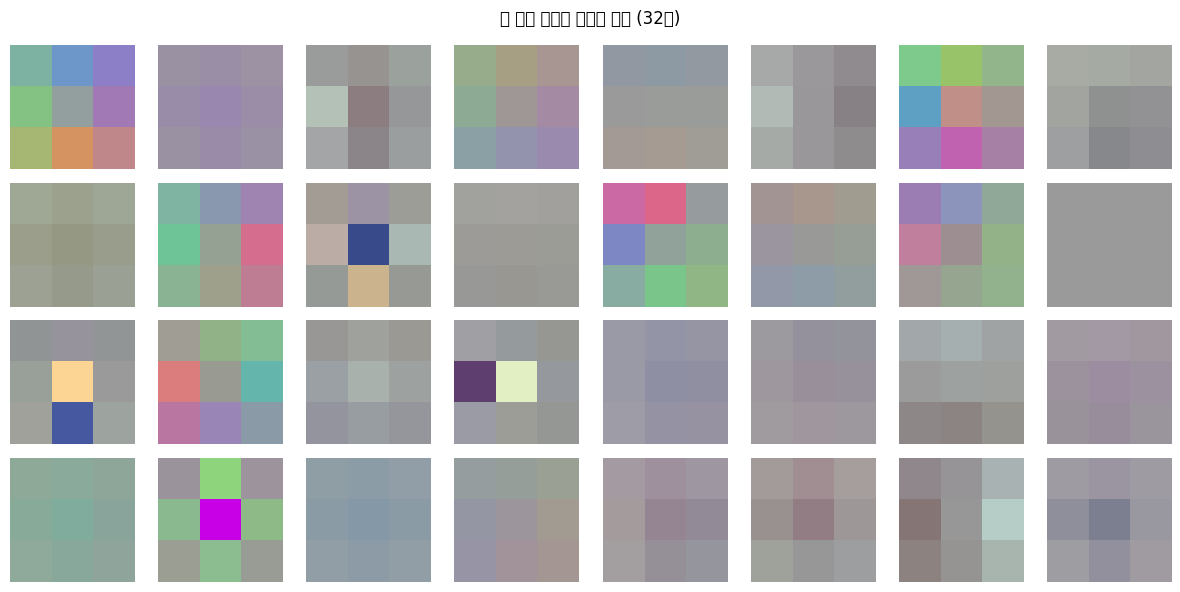

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 학습된 모델의 첫 번째 Conv 레이어 가중치
weights = model.block1[0].weight.data.cpu()  # [32, 3, 3, 3]
print(f"필터 shape: {weights.shape}")  # [필터수, 채널, H, W]

# 필터 정규화 (시각화용)
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min)

# 32개 필터 시각화
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        # RGB 채널 합성 (3채널 → 시각화)
        filt = weights[i].permute(1, 2, 0).numpy()  # [3,3,3] → [3,3,3] HWC
        ax.imshow(filt)
    ax.axis('off')
plt.suptitle("첫 번째 합성곱 레이어 필터 (32개)", fontsize=12)
plt.tight_layout()
plt.show()

특징 맵(Feature Map) 시각화

/tmp/ipykernel_10067/853677500.py:30: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/853677500.py:30: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/853677500.py:30: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/853677500.py:30: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/853677500.py:30: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/853677500.py:30: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/853677500.py:30: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  plt.tig

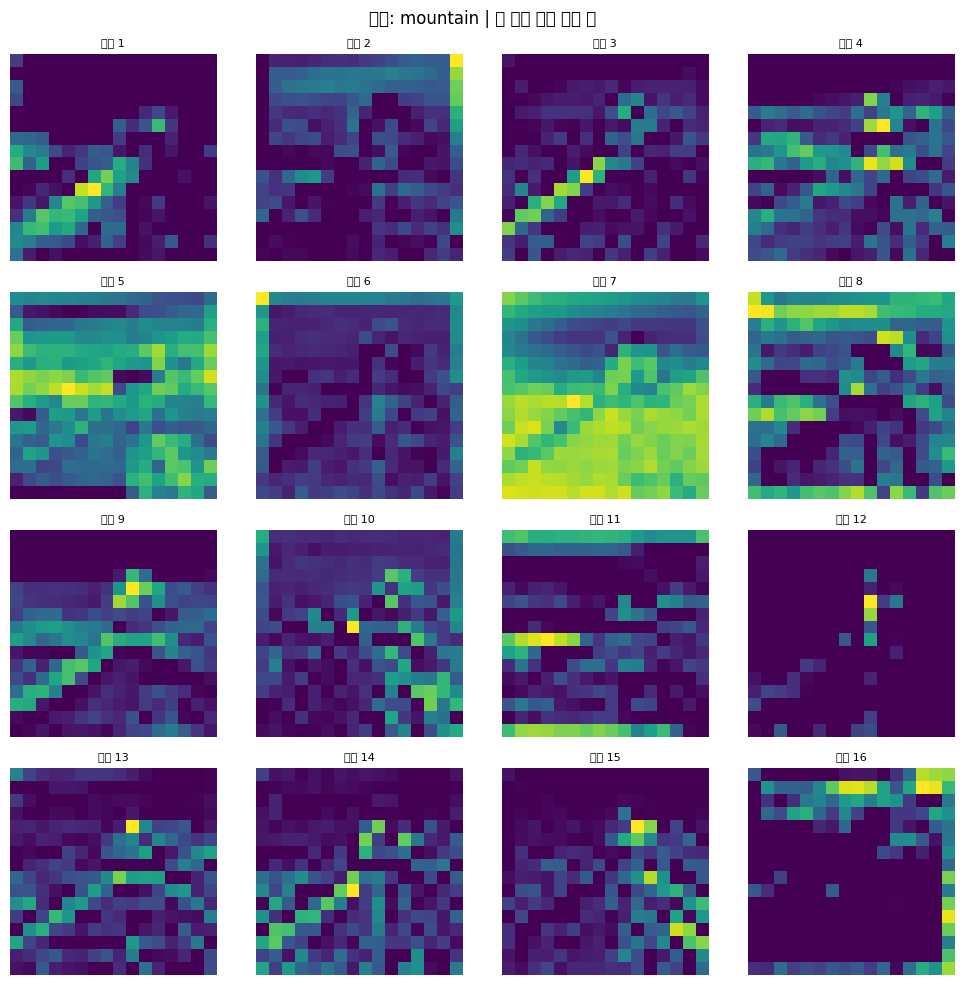

In [10]:
# 테스트 이미지 1장 가져오기
image, label = test_dataset[0]
image_tensor = image.unsqueeze(0).to(device)  # [1, 3, 32, 32]

# 첫 번째 블록의 출력 추출 (hook 사용)
feature_maps = {}

def hook_fn(module, input, output):
    feature_maps['block1'] = output.detach().cpu()

hook = model.block1.register_forward_hook(hook_fn)

# 순전파 실행
model.eval()
with torch.no_grad():
    _ = model(image_tensor)

hook.remove()

# 특징 맵 시각화 (32개 채널 중 16개)
fmaps = feature_maps['block1'][0]  # [32, 16, 16]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[i].numpy(), cmap='viridis')
    ax.set_title(f"필터 {i+1}", fontsize=8)
    ax.axis('off')

# 원본 이미지도 함께 표시
plt.suptitle(f"원본: {classes[label]} | 첫 번째 블록 특징 맵", fontsize=12)
plt.tight_layout()
plt.show()


클래스별 예측 확인

/tmp/ipykernel_10067/2593054829.py:26: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2593054829.py:26: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2593054829.py:26: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2593054829.py:26: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2593054829.py:26: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2593054829.py:26: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2593054829.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
 

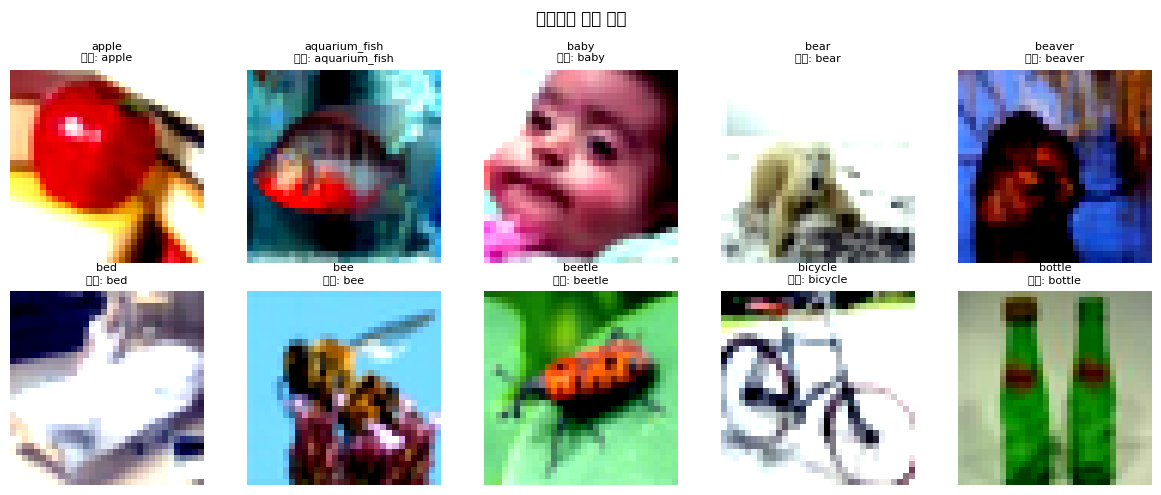

In [11]:
# 각 클래스별로 올바르게 예측한 예시와 틀린 예시 시각화
model.eval()
class_correct = {c: [] for c in classes}
class_wrong   = {c: [] for c in classes}

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.max(1)[1].cpu()
        for img, true, pred in zip(images, labels, preds):
            cls = classes[true.item()]
            if true == pred and len(class_correct[cls]) < 2:
                class_correct[cls].append((img, pred.item()))
            elif true != pred and len(class_wrong[cls]) < 2:
                class_wrong[cls].append((img, pred.item()))

# 클래스별 맞춘 사례 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, (cls, ax) in enumerate(zip(classes, axes.flat)):
    if class_correct[cls]:
        img, pred = class_correct[cls][0]
        ax.imshow(img.permute(1, 2, 0).numpy() * 0.5 + 0.5)
        ax.set_title(f"{cls}\n예측: {classes[pred]}", fontsize=8)
    ax.axis('off')
plt.suptitle("클래스별 정답 예시", fontsize=12)
plt.tight_layout()
plt.show()


혼동 행렬로 오류 분석

/tmp/ipykernel_10067/2992927853.py:21: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2992927853.py:21: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2992927853.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2992927853.py:21: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2992927853.py:21: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2992927853.py:21: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10067/2992927853.py:21: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
 

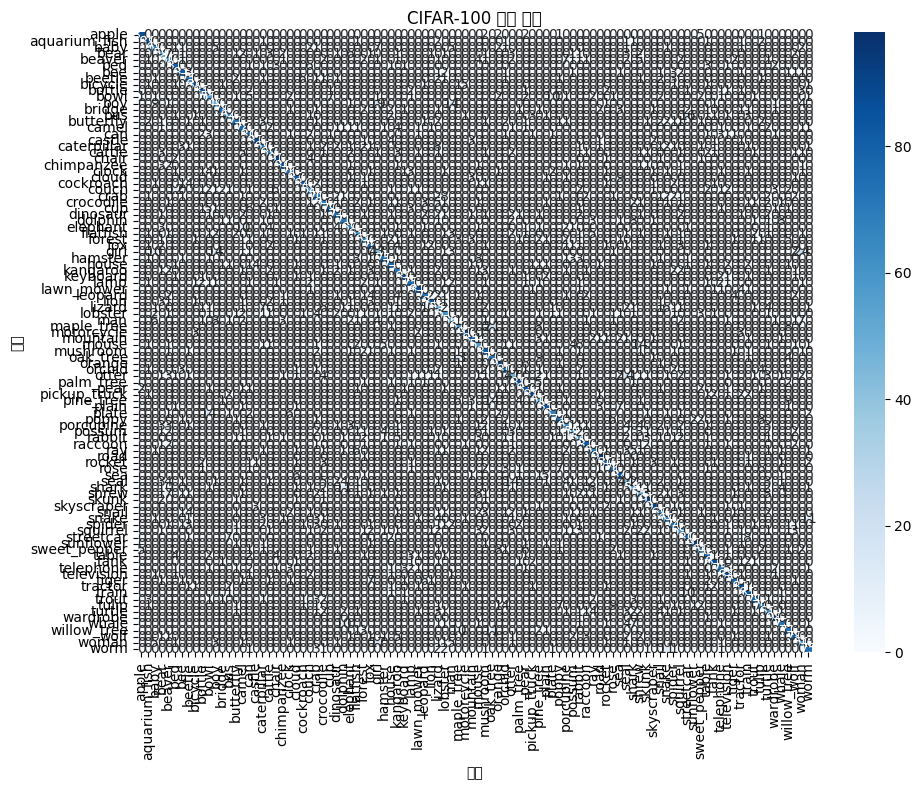

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.max(1)[1].cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('예측')
plt.ylabel('정답')
plt.title('CIFAR-100 혼동 행렬')
plt.tight_layout()
plt.show()
